In [ ]:
# Maxima H  PRADA --- --- 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 
from Bio import SeqIO
from sklearn import metrics  

In [ ]:
## 1. Extend Figure 8h-8j --- --- 
### 1_1. Extend Fig8h --- --- 
### 1_2. Extend Fig8i --- --- 
### 1_3. Extend Fig8j  --- --- 

In [ ]:
### 1_1. Extend Fig8h --- --- 

In [2]:
dir = "./Data/"
maximaH_prada = pd.read_csv(dir+"maximaH_PRADA_heavy_NC_012920.1_profile.txt",sep='\t')

maximaH_prada_label = maximaH_prada[maximaH_prada['Modified_effective_depth'] >=5000]
print(maximaH_prada.shape)
print(maximaH_prada_label.shape)
maximaH_prada_label = maximaH_prada_label[['Nucleotide','Sequence','Modified_rate']]
maximaH_prada_label.columns=['Nucleotide','Sequence','mod_rate']
maximaH_prada_label['group'] = 'Label'

maximaH_prada_ctrl = maximaH_prada[maximaH_prada['Untreated_effective_depth'] >=5000]
print(maximaH_prada.shape)
print(maximaH_prada_ctrl.shape)
maximaH_prada_ctrl = maximaH_prada_ctrl[['Nucleotide','Sequence','Untreated_rate']]
maximaH_prada_ctrl.columns=['Nucleotide','Sequence','mod_rate']
maximaH_prada_ctrl['group'] = 'Ctrl'

maximaH_prada_flt = pd.concat([maximaH_prada_label,maximaH_prada_ctrl])
dplot = maximaH_prada_flt 

dplot.to_csv('./Data/'+'source_data_Efig8h.csv',sep=',') 

(16569, 29)
(15227, 29)
(16569, 29)
(13005, 29)


G_Label v.s. G_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.280e-126 U_stat=2.335e+06
U_Label v.s. U_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=4.524e-291 U_stat=9.098e+06
A_Label v.s. A_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.679e-18 U_stat=1.043e+07
C_Label v.s. C_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.245e-172 U_stat=1.343e+07
                mod_rate
Sequence group          
A        Ctrl   0.001762
         Label  0.002030
C        Ctrl   0.002508
         Label  0.003603
G        Ctrl   0.002980
         Label  0.005630
N        Label  0.019785
U        Ctrl   0.003489
         Label  0.006713


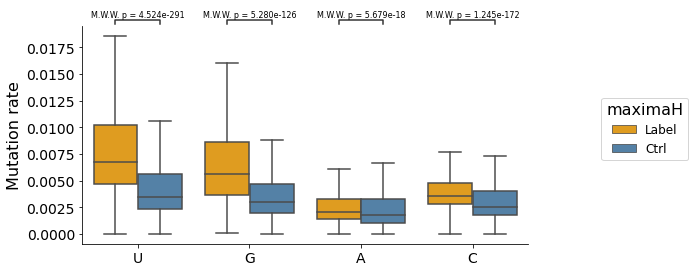

In [3]:
#### plot --- --- 

plt.figure(figsize=(8,4))
order = ['U','G', 'A',  'C']
my_pal = {'Label': "orange", 'Ctrl': "steelblue"}

ax = sns.boxplot(data=dplot, x='Sequence',y='mod_rate', hue='group',showfliers = False,order = order, palette = my_pal)     
plt.title(' ',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Mutation rate',fontsize = 16)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14) 
legend=plt.legend(loc='best', title='maximaH',bbox_to_anchor=(1.15, 0.7),prop={'size': 12})
legend.get_title().set_fontsize('16') 
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data=dplot, x='Sequence',y='mod_rate', hue='group', order=order, 
                    box_pairs = [(("U", 'Label'), ("U", 'Ctrl')),
                                 (("A", 'Label'), ("A", 'Ctrl')),
                                 (("C", 'Label'), ("C", 'Ctrl')),
                                 (("G", 'Label'), ("G", 'Ctrl'))
                                ],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.01, verbose=1,fontsize=8)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig8h_maximaH_PRADA_mutrate_label_vs_Ctrl.pdf',bbox_inches='tight', dpi=300) 

print(dplot.groupby(['Sequence','group']).median()[['mod_rate']])  

In [4]:
print(dplot.groupby(['Sequence','group']).mean()[['mod_rate']])  

                mod_rate
Sequence group          
A        Ctrl   0.004795
         Label  0.005591
C        Ctrl   0.005444
         Label  0.006059
G        Ctrl   0.008528
         Label  0.010915
N        Label  0.019785
U        Ctrl   0.005440
         Label  0.009022


In [5]:
print(dplot.groupby(["Sequence", "group"]).count())  

                Nucleotide  mod_rate
Sequence group                      
A        Ctrl         3993      3993
         Label        4709      4709
C        Ctrl         4191      4191
         Label        4774      4774
G        Ctrl         1617      1617
         Label        1973      1973
N        Label           1         1
U        Ctrl         3204      3204
         Label        3770      3770


In [ ]:
### 1_2. Extend Fig8i --- --- 

In [6]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

/tmp/ipykernel_124679/1273734862.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp1['region'] = 'SS'
/tmp/ipykernel_124679/1273734862.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp2['region'] = 'DS'
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(1602, 8)
p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

SS v.s. DS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.175e-14 U_stat=2.312e+04
        Nucleotide  Sequence  Modified_effective_depth  \
region                                                   
DS              94        94                        94   
SS             324       324                       324   

        Untreated_effective_depth  Modified_rate  Untreated_rate  \
region                                                             
DS                             94             94              94   
SS                            324            324             324   

        Reactivity_profile  Norm_profile  Position2  base  dot  strand  
region                                                                  
DS                      94            94         94    94   94  

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

SS v.s. DS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=4.822e-15 U_stat=1.318e+04
        Nucleotide  Sequence  Modified_effective_depth  \
region                                                   
DS             137       137                       137   
SS             125       125                       125   

        Untreated_effective_depth  Modified_rate  Untreated_rate  \
region                                                             
DS                            137            137             137   
SS                            125            125             125   

        Reactivity_profile  Norm_profile  Position2  base  dot  strand  
region                                                                  
DS                     137           136        137   137  137     137  
S

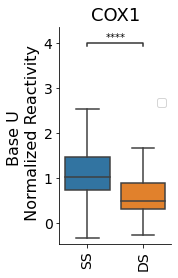

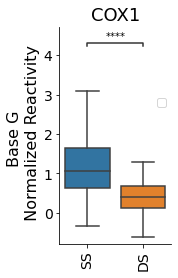

In [7]:
#### normalzied reactivity --- --- 

dir = "./Data/"
maximaH_prada = pd.read_csv(dir+"maximaH_PRADA_heavy_NC_012920.1_profile.txt",sep='\t')
maximaH_prada = maximaH_prada[(maximaH_prada['Modified_effective_depth'] >=5000) & (maximaH_prada['Untreated_effective_depth'] >=5000)]
cox1= maximaH_prada[(maximaH_prada['Nucleotide']>=5900) & (maximaH_prada['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899 
cox1['Position2'] =cox1['Nucleotide']

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

df = pd.merge(cox1,bench, how='left',on=['Position2','Position2']) 
dplot=df
tmp1 = dplot[dplot['strand'] == 1]
tmp1['region'] = 'SS'
tmp2 = dplot[dplot['strand'] == 0]
tmp2['region'] = 'DS'
dplot = pd.concat([tmp1,tmp2], ignore_index=True)

#### plots Base U --------------------------------

dplott = dplot[(dplot['base'] =='T') | (dplot['base'] =='U')]
dplott.to_csv('./Data/'+'source_data_Efig8i.csv',sep=',')

plt.figure(figsize=(2,4))
order = ['SS', 'DS']
ax = sns.boxplot(data=dplott, x='region',y='Norm_profile', showfliers = False,order = order, dodge = False) 
plt.title('COX1',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Base U \n Normalized Reactivity',fontsize = 16)
plt.xticks(fontsize = 14,rotation=90) 
plt.yticks(fontsize = 14)
#plt.yticks([-2.0,-1.0, 0.0, 1.0,2.0],fontsize = 14)  
plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['Norm_profile'], order=order, 
                    box_pairs = [('SS','DS')],
                    test="Mann-Whitney", text_format='star', loc='inside', line_offset_to_box=0.1, verbose=3)  

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig8i_maximaH_PRADA_baseU_SS_vs_DS.pdf',bbox_inches='tight', dpi=300) 
print(dplott.groupby(["region"]).count())  

#### plots Base G --------------------------------

dplott = dplot[(dplot['base'] =='G')]
dplott.to_csv('./Data/'+'source_data_Efigg8i.csv',sep=',')

plt.figure(figsize=(2,4))
order = ['SS', 'DS']
ax = sns.boxplot(data=dplott, x='region',y='Norm_profile', showfliers = False,order = order, dodge = False) 
plt.title('COX1',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Base G \n Normalized Reactivity',fontsize = 16)
plt.xticks(fontsize = 14,rotation=90) 
#plt.yticks([-1.0, 0.0, 1.0],fontsize = 14) 
plt.yticks(fontsize = 14) 
plt.legend(loc='best', bbox_to_anchor=(1.01, 0.7),prop={'size': 12})
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data = dplott, x = dplott['region'], y = dplott['Norm_profile'], order=order, 
                    box_pairs = [('SS','DS')],
                    test="Mann-Whitney", text_format='star', loc='inside', line_offset_to_box=0.1, verbose=3)  

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig8i_maximaH_PRADA_baseG_SS_vs_DS.pdf',bbox_inches='tight', dpi=300) 
print(dplott.groupby(["region"]).count())  

In [ ]:
### 1_3. Extend Fig8j --- --- 

(1602, 8)
0.7619024166009982
0.7800583941605839
0.7867844850027479


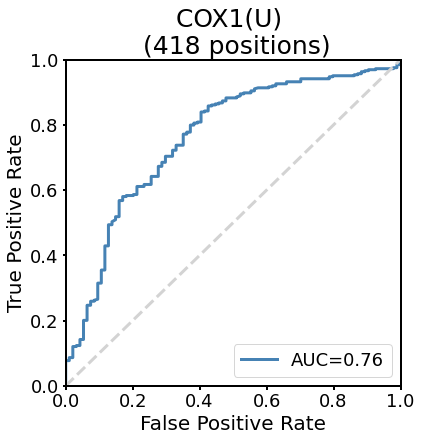

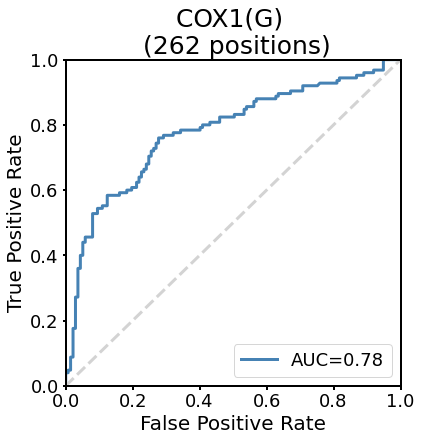

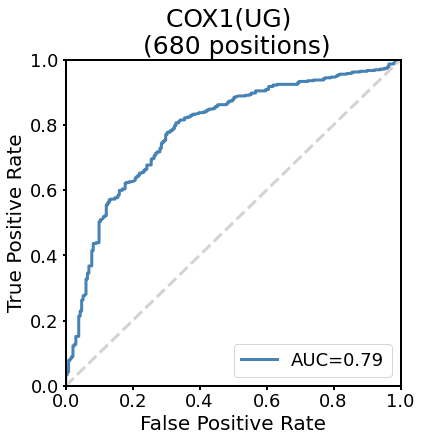

In [8]:
dir = "./Data/"
maximaH_prada = pd.read_csv(dir+"maximaH_PRADA_heavy_NC_012920.1_profile.txt",sep='\t')
maximaH_prada = maximaH_prada[(maximaH_prada['Modified_effective_depth'] >=5000) & (maximaH_prada['Untreated_effective_depth'] >=5000)]
cox1= maximaH_prada[(maximaH_prada['Nucleotide']>=5900) & (maximaH_prada['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899 
cox1['Position2'] =cox1['Nucleotide']

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

df = pd.merge(cox1,bench, how='left',on=['Position2','Position2']) 

## plot U--------------------------

flt=df[(df['base']=='T')]
flt.to_csv('./Data/'+'source_data_Efig8ju.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)
    
fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('COX1(U) '+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)
plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig8j_maximaH_PRADA_baseU_AUROC.pdf',bbox_inches='tight', dpi=300) 


## plot G--------------------------

flt=df[(df['base']=='G')]
flt.to_csv('./Data/'+'source_data_Efig8jg.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)
    
fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('COX1(G) '+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)
plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig8j_maximaH_PRADA_baseG_AUROC.pdf',bbox_inches='tight', dpi=300) 


## plot UG--------------------------

flt=df[(df['base']=='G') | (df['base']=='T')]
flt.to_csv('./Data/'+'source_data_Efig8jug.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)
    
fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('COX1(UG) '+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)
plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig8j_maximaH_PRADA_baseUG_AUROC.pdf',bbox_inches='tight', dpi=300) 

